# Analytical Baselines

Hierarchical Roofline for F-DATA; PM100 calibrated resource-utilization power model, including the training-period-only coefficient calibration step.

See the conceptualization plan and EXPERIMENT_TRACKER.md for full context.

In [1]:
import sys
sys.path.append("..")

import glob

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src import config, features, metrics, plotting, models, roofline, splits, baselines

## Load data

This notebook doesn't touch F-DATA's `embedding` column, so the memory constraint behind notebooks 01/02's load pattern doesn't apply -- `load_fdata_no_embedding` over all 38 months costs ~27 GB. Following the move to the replacement workstation this runs on the **full** F-DATA dataset (all 38 contiguous months, ~23.3M completed jobs), not the earlier 6-month dev slice. PM100 loads in full, as it has throughout -- it's small enough not to need sampling, and its results here are unchanged from the dev-scale runs since PM100 was never subsampled.

In [2]:
FDATA_DIR = "../data/raw/fdata"
PM100_PATH = "../data/raw/pm100/pm100_job_table.parquet"
N_CONSECUTIVE_MONTHS = 38  # full F-DATA -- every month

fdata_files = sorted(glob.glob(f"{FDATA_DIR}/*.parquet"))[:N_CONSECUTIVE_MONTHS]
print(f"Loading {len(fdata_files)} consecutive F-DATA months:",
      [f.split('/')[-1] for f in fdata_files])

fdata = features.load_fdata_no_embedding(fdata_files)
fdata["adt"] = pd.to_datetime(fdata["adt"], errors="coerce")  # parse once here; chronological_split reuses it
pm100 = pd.read_parquet(PM100_PATH)

print(f"\nF-DATA: {len(fdata):,} rows | PM100: {len(pm100):,} rows")

Loading 38 consecutive F-DATA months: ['21_03.parquet', '21_04.parquet', '21_05.parquet', '21_06.parquet', '21_07.parquet', '21_08.parquet', '21_09.parquet', '21_10.parquet', '21_11.parquet', '21_12.parquet', '22_01.parquet', '22_02.parquet', '22_03.parquet', '22_04.parquet', '22_05.parquet', '22_06.parquet', '22_07.parquet', '22_08.parquet', '22_09.parquet', '22_10.parquet', '22_11.parquet', '22_12.parquet', '23_01.parquet', '23_02.parquet', '23_03.parquet', '23_04.parquet', '23_05.parquet', '23_06.parquet', '23_07.parquet', '23_08.parquet', '23_09.parquet', '23_10.parquet', '23_11.parquet', '23_12.parquet', '24_01.parquet', '24_02.parquet', '24_03.parquet', '24_04.parquet']



F-DATA: 25,866,900 rows | PM100: 231,238 rows


## Exclude non-completed jobs, reduce PM100's power trace to a scalar

Same filter as notebook 02 — a job that never finished doesn't have a meaningful duration or power draw to predict. PM100's `node_power_consumption` is a 20-second-interval time series per job (its native form, used later for LSTM/TCN), so for this notebook's per-job calibration/prediction task it's reduced to its per-job mean here, same as notebook 01's plotting code did.

In [3]:
fdata = features.filter_completed_jobs(fdata, "fdata")
pm100 = features.filter_completed_jobs(pm100, "pm100")

pm100["power_mean"] = pm100["node_power_consumption"].apply(np.mean)

[fdata] excluded 9.9% of jobs as non-completed (2558519 / 25866900)
[pm100] excluded 22.0% of jobs as non-completed (50928 / 231238)


## Chronological split (Shared Context)

`src/splits.py` is the single source of truth for the split boundary — train on earlier submission times, test on later ones, 70/30 by row count — so every notebook from here on (this one, classical ML, DL, the hybrid model, evaluation) compares models against the same boundary rather than each notebook picking its own.

In [4]:
fdata_train, fdata_test = splits.chronological_split(fdata, "fdata", train_frac=0.7)
pm100_train, pm100_test = splits.chronological_split(pm100, "pm100", train_frac=0.7)

print("F-DATA split boundary:", splits.split_boundary(fdata, "fdata"))
print(f"  train: {len(fdata_train):,} rows | test: {len(fdata_test):,} rows")
print()
print("PM100 split boundary:", splits.split_boundary(pm100, "pm100"))
print(f"  train: {len(pm100_train):,} rows | test: {len(pm100_test):,} rows")

F-DATA split boundary: 2023-06-08 17:45:53+09:00
  train: 16,315,867 rows | test: 6,992,514 rows

PM100 split boundary: 2020-09-19 08:28:53.300000+00:00
  train: 126,217 rows | test: 54,093 rows


# Part 1: F-DATA — Hierarchical Roofline

F-DATA is the only one of the two datasets with real FLOP/performance-counter fields, so it's the only one that supports a genuine Roofline analysis. Three fields matter here:

- `flops` — total floating-point operations measured for the job (hardware performance counters).
- `mbwidth` — total bytes moved between memory and the compute cores over the job's lifetime.
- `opint` — operational/arithmetic intensity, precomputed by F-DATA's own authors as `flops / mbwidth` (checked below, not assumed).
- `pclass` — F-DATA's own precomputed compute-bound/memory-bound label for the job.

The ceiling comes from A64FX's published peak specs (Fugaku's node architecture): 3.3792 TFLOP/s double-precision peak and 1024 GB/s peak HBM2 bandwidth, both **per node**. Just like `avgpcon` (notebook 02's units investigation), `flops` and `mbwidth` turn out to be **job-wide totals across all allocated nodes**, not per-node quantities — checked directly below before the ceiling is applied, rather than assumed from the field names.

In [5]:
rel_error = (np.abs(fdata["opint"] - fdata["flops"] / fdata["mbwidth"]) / fdata["opint"]).max()
print(f"opint vs. flops/mbwidth, max relative error across {len(fdata):,} jobs: {rel_error:.2e}")

perf = fdata["flops"] / fdata["duration"].replace(0, np.nan)
peak_single_node = roofline.A64FX_PEAK_DP_FLOPS_PER_NODE

n_exceed_raw = (perf > peak_single_node).sum()
n_exceed_per_node = (perf / fdata["nnuma"] > peak_single_node).sum()
print(f"\nJobs exceeding single-node peak FLOP/s, nnuma ignored:   {n_exceed_raw:,} / {len(fdata):,}")
print(f"Jobs exceeding single-node peak FLOP/s, divided by nnuma: {n_exceed_per_node:,} / {len(fdata):,}")
if n_exceed_raw:
    print("Median nnuma among the jobs that exceed it (nnuma ignored):",
          fdata.loc[perf > peak_single_node, "nnuma"].median())

opint vs. flops/mbwidth, max relative error across 23,308,381 jobs: 0.00e+00

Jobs exceeding single-node peak FLOP/s, nnuma ignored:   2,689 / 23,308,381
Jobs exceeding single-node peak FLOP/s, divided by nnuma: 0 / 23,308,381


Median nnuma among the jobs that exceed it (nnuma ignored): 6000.0


In [6]:
fdata_roofline = roofline.hierarchical_roofline_fdata(fdata)

agreement = (fdata_roofline["pclass"] == fdata_roofline["roofline_pclass"]).mean()
print(f"Recomputed roofline_pclass agrees with F-DATA's own precomputed pclass "
      f"in {agreement:.4%} of jobs")
print(f"Ridge point (single-node): "
      f"{roofline.A64FX_PEAK_DP_FLOPS_PER_NODE / roofline.A64FX_PEAK_HBM_BW_PER_NODE:.2f} FLOP/byte")

Recomputed roofline_pclass agrees with F-DATA's own precomputed pclass in 99.9739% of jobs
Ridge point (single-node): 3.30 FLOP/byte


### Classification metrics for the pclass check

The agreement percentage above is a single accuracy number. If one regime dominates F-DATA's job mix and the recomputed classifier simply predicted the majority class everywhere, agreement would still look high while the minority regime was never recovered. `classification_report` breaks the same `pclass` vs `roofline_pclass` comparison out per class (precision / recall / F1 for compute-bound and for memory-bound separately), which surfaces that blind spot. It supplements the agreement number, not replaces it.

In [7]:
from sklearn.metrics import classification_report

# Label-encode to category codes first: classification_report on ~23M
# object-string rows is ~10x slower for a byte-identical report.
_cats = sorted(set(fdata_roofline["pclass"]) | set(fdata_roofline["roofline_pclass"]))
_pc = pd.Categorical(fdata_roofline["pclass"], categories=_cats)
_rp = pd.Categorical(fdata_roofline["roofline_pclass"], categories=_cats)
print(classification_report(_pc.codes, _rp.codes, target_names=_cats, digits=4))

               precision    recall  f1-score   support

compute-bound     1.0000    0.9993    0.9996   8669755
 memory-bound     0.9996    1.0000    0.9998  14638626

     accuracy                         0.9997  23308381
    macro avg     0.9998    0.9996    0.9997  23308381
 weighted avg     0.9997    0.9997    0.9997  23308381



### Roofline chart

Both axes are per-node quantities: `opint` is already node-count invariant (both `flops` and `mbwidth` scale by `nnuma` equally, so the ratio doesn't), and achieved performance is divided by `nnuma` so every job — single-node or 150,000-node — plots against the same fixed ceiling curve.

/home/bizon/Documents/tobi/hpc-dl-enhanced/notebooks/../src/plotting.py:95: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.tight_layout()


/home/bizon/Documents/tobi/hpc-dl-enhanced/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


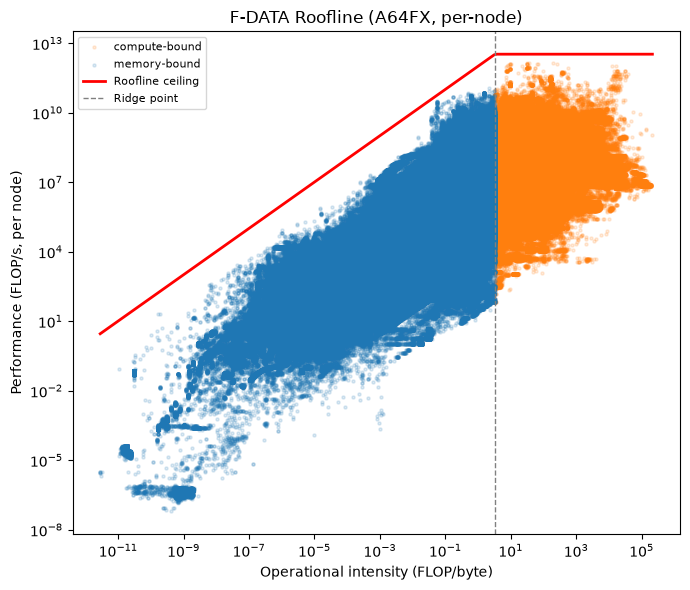

In [8]:
fig = plotting.plot_roofline(
    fdata_roofline["opint"].to_numpy(),
    fdata_roofline["achieved_flops_per_sec_per_node"].to_numpy(),
    roofline.A64FX_PEAK_DP_FLOPS_PER_NODE,
    roofline.A64FX_PEAK_HBM_BW_PER_NODE,
    pclass=fdata_roofline["pclass"].to_numpy(),
)
plt.show()

## Roofline as an execution-time baseline

The ceiling implies a best-case duration for each job: `flops / roofline_ceiling_flops_per_sec` — how long the job would take if it ran at the fastest rate its own measured operational intensity allows. Evaluated on the test split, against the naive per-user-median baseline (a trivial floor — Roofline is physics-informed, not "dumb," so this shows how much of any accuracy is genuine signal versus just reflecting a user's recent typical behavior) computed from the training split only.

In [9]:
fdata_test_roofline = roofline.hierarchical_roofline_fdata(fdata_test)
valid = np.isfinite(fdata_test_roofline["roofline_predicted_duration"].to_numpy())
print(f"Valid Roofline predictions: {valid.sum():,} / {len(fdata_test_roofline):,}")

roofline_metrics = metrics.regression_metrics(
    fdata_test_roofline.loc[valid, "duration"].to_numpy(),
    fdata_test_roofline.loc[valid, "roofline_predicted_duration"].to_numpy(),
)
print("\nRoofline baseline (F-DATA execution time, test period):")
for k, v in roofline_metrics.items():
    print(f"  {k}: {v:,.4f}")

user_med, glob_med = baselines.fit_naive_baseline(fdata_train, "fdata", "duration")
naive_pred = baselines.predict_naive_baseline(fdata_test, "fdata", user_med, glob_med)
naive_metrics = metrics.regression_metrics(fdata_test["duration"].to_numpy(), naive_pred)
print("\nNaive per-user-median baseline (F-DATA execution time, test period):")
for k, v in naive_metrics.items():
    print(f"  {k}: {v:,.4f}")

Valid Roofline predictions: 6,992,514 / 6,992,514



Roofline baseline (F-DATA execution time, test period):
  MAE: 10,517.6011
  RMSE: 27,993.7073
  R2: -0.1644
  MAPE: 99.9848
  MedAE: 1,803.8535
  Within20pct: 0.0000



Naive per-user-median baseline (F-DATA execution time, test period):
  MAE: 9,702.8785
  RMSE: 24,889.4708
  R2: 0.0796
  MAPE: 8,368.7861
  MedAE: 1,276.0000
  Within20pct: 14.8090


**Roofline sits well below zero R² (-0.16); the naive per-user median just clears it (0.08).** Roofline's ceiling assumes a job runs at the fastest rate its measured operational intensity allows for its entire wall-clock duration — real jobs spend time on I/O, synchronization, and non-compute phases the ceiling doesn't model, so predicted durations come out roughly five orders of magnitude below actual (mean predicted ~0.06 s against a test-set mean actual of 10,518 s) and MAPE saturates at 99.98%, the prediction being near zero relative to any real duration. The naive per-user median (R² 0.08, MAE 9,703 s) edges just past predicting the flat training-period mean for every job — across all 38 months there is enough per-user history for it to carry a little signal, unlike the 6-month dev slice where the same baseline came out slightly negative (R² -0.10). Its MAPE (8,369%) is still an extreme case of the metric's blow-up when actual values sit near zero (F-DATA's minimum duration is 1 second), which is why it is read here alongside MAE/RMSE/R² rather than alone. Both entries are the floor the later models (RF/XGBoost/LightGBM, FNN/LSTM/TCN, Hybrid) need to clear.

# Part 2: PM100 — Calibrated Resource-Utilization Power Model

PM100's schema has zero FLOP/instruction/performance-counter fields, so no Roofline-family metric is computable here — confirmed against `documentation/job_features.md`, not assumed. Instead: a resource-utilization power model whose functional form is fixed by hardware reasoning (an idle baseline plus a linear contribution per allocated resource type), with only the coefficients calibrated against measured power on a training-period-only subset.

**Correction to a prior assumption:** `node_power_consumption`'s name — and an earlier pass over this codebase — suggested it's a genuine per-node reading. It isn't. Checked directly below: dividing each job's mean power by `num_nodes_alloc` gives a stable per-node figure across every node count from 1 to 32+, which is only possible if the recorded value is already summed across all allocated nodes at each 20-second sample — the same kind of job-total-not-per-node quantity `avgpcon` turned out to be in F-DATA (notebook 02). The calibrated model below is built for the corrected, job-total interpretation: `P_idle` scales by `num_nodes_alloc` rather than being applied once per job.

In [10]:
for n in [1, 2, 4, 8, 16, 32]:
    sub = pm100[pm100["num_nodes_alloc"] == n]
    if len(sub):
        total = sub["power_mean"].mean()
        print(f"{n:>3} nodes: mean total power {total:>10.1f} W "
              f"-> per-node {total/n:>7.1f} W  (n={len(sub):,})")

  1 nodes: mean total power      731.1 W -> per-node   731.1 W  (n=139,620)
  2 nodes: mean total power     1440.3 W -> per-node   720.1 W  (n=14,067)
  4 nodes: mean total power     2869.5 W -> per-node   717.4 W  (n=5,668)
  8 nodes: mean total power     5614.8 W -> per-node   701.8 W  (n=3,591)
 16 nodes: mean total power    10836.8 W -> per-node   677.3 W  (n=8,203)
 32 nodes: mean total power    23428.8 W -> per-node   732.1 W  (n=1,405)


### Figure: per-node-normalized power holds roughly constant across node counts

If `node_power_consumption` were already per-node, this bar chart would show power falling or rising with node count as jobs at different scales have different characteristics. Instead it should stay roughly flat around Marconi100's known per-node draw — evidence the raw field is a job-wide total.

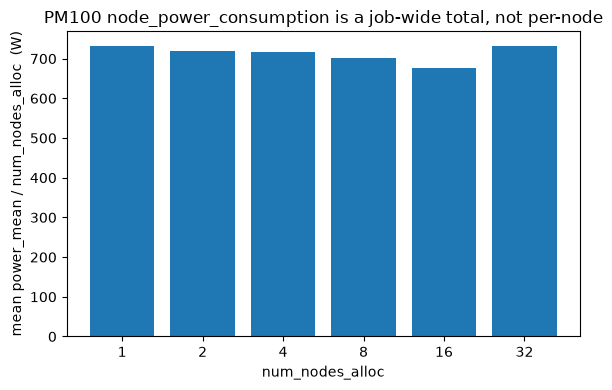

In [11]:
node_counts = [1, 2, 4, 8, 16, 32]
per_node_means = []
labels = []
for n in node_counts:
    sub = pm100[pm100["num_nodes_alloc"] == n]
    if len(sub):
        per_node_means.append(sub["power_mean"].mean() / n)
        labels.append(str(n))

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(labels, per_node_means)
ax.set_xlabel("num_nodes_alloc")
ax.set_ylabel("mean power_mean / num_nodes_alloc  (W)")
ax.set_title("PM100 node_power_consumption is a job-wide total, not per-node")
fig.tight_layout()
plt.show()

### A caveat before calibrating: the four predictors are highly correlated

Marconi100 nodes have a fixed core:GPU:memory ratio, so jobs requesting more of one resource almost always request proportionally more of the others. This matters for how the calibrated coefficients should be read — an OLS fit can land on odd-looking (even negative) individual coefficients under near-collinear inputs even when the model's overall predictions are reasonable, because the fit can't cleanly attribute the outcome to one input over its correlated neighbors.

In [12]:
predictor_cols = ["num_nodes_alloc", "num_cores_alloc", "num_gpus_alloc", "mem_alloc"]
print(pm100_train[predictor_cols].corr())

                 num_nodes_alloc  num_cores_alloc  num_gpus_alloc  mem_alloc
num_nodes_alloc         1.000000         0.879568        0.974315   0.909763
num_cores_alloc         0.879568         1.000000        0.854061   0.972646
num_gpus_alloc          0.974315         0.854061        1.000000   0.876804
mem_alloc               0.909763         0.972646        0.876804   1.000000


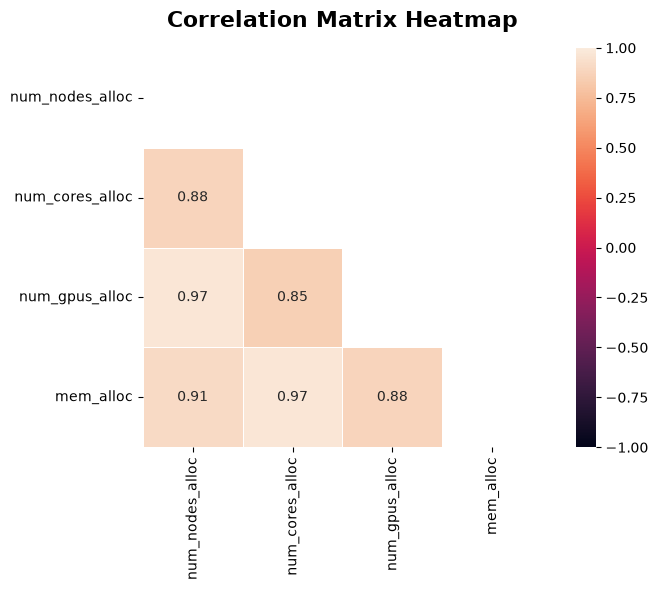

In [13]:
# 2. Calculate the correlation matrix
corr_matrix = pm100_train[predictor_cols].corr()

# 3. Create a mask to hide the redundant upper triangle
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# 4. Set up the matplotlib figure
plt.figure(figsize=(8, 6))

# 5. Plot the heatmap
sns.heatmap(
    corr_matrix, 
    mask=mask, 
    annot=True,          # Show correlation coefficients
    fmt=".2f",          # Round numbers to 2 decimal places
    # cmap='coolwarm',     # Use a divergent color palette (blue to red)
    vmin=-1, vmax=1,     # Explicitly set color bounds for correlation
    square=True,         # Force cells to be perfect squares
    linewidths=0.5       # Add small gaps between cells
)

# 6. Add title and display
plt.title('Correlation Matrix Heatmap', fontsize=16, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

## Calibration

`calibrate_pm100_power_model` fits `P_idle, alpha, beta, gamma` via OLS on `pm100_train` only — the test split is never touched by this step.

In [14]:
coeffs = roofline.calibrate_pm100_power_model(pm100_train)
print(coeffs)
print(f"\nPlausibility check — published TDPs: 2x POWER9 CPU ~= 380W, 4x V100 GPU ~= 1200W per node.")
print(f"Calibrated P_idle: {coeffs.p_idle:.1f} W")
print(f"Calibrated alpha (per core): {coeffs.alpha:.3f} W, beta (per GPU): {coeffs.beta:.3f} W, "
      f"gamma (per MB mem): {coeffs.gamma:.5f} W")

PM100PowerModelCoefficients(p_idle=747.5676241204941, alpha=0.2555407097572875, beta=-23.674039878856245, gamma=-0.12571614086283034)

Plausibility check — published TDPs: 2x POWER9 CPU ~= 380W, 4x V100 GPU ~= 1200W per node.
Calibrated P_idle: 747.6 W
Calibrated alpha (per core): 0.256 W, beta (per GPU): -23.674 W, gamma (per MB mem): -0.12572 W


### Figure: predicted vs. actual power on the calibration (training-period) subset

PM100's equivalent of a Roofline chart — this is the evidence that the analytical prior is sound, in place of a Roofline plot (which PM100 can't support).

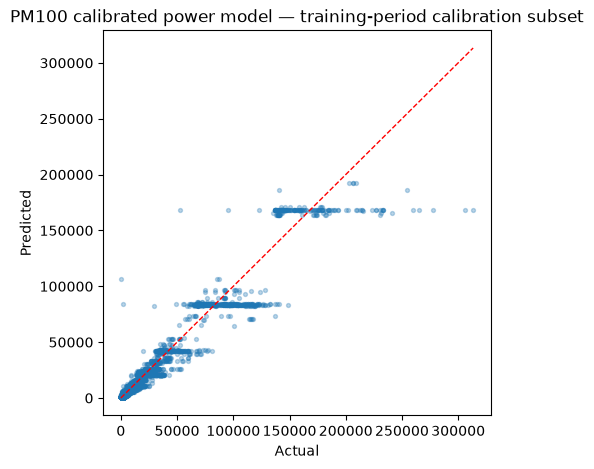

Calibration-subset fit:
  MAE: 446.5075
  RMSE: 2,028.7893
  R2: 0.9502
  MAPE: 20.5596
  MedAE: 139.2860
  Within20pct: 49.2453


In [15]:
pred_train = roofline.predict_pm100_power(pm100_train, coeffs)
fig = plotting.plot_predicted_vs_actual(
    pm100_train["power_mean"].to_numpy(), pred_train,
    "PM100 calibrated power model — training-period calibration subset",
)
plt.show()

train_metrics = metrics.regression_metrics(pm100_train["power_mean"].to_numpy(), pred_train)
print("Calibration-subset fit:")
for k, v in train_metrics.items():
    print(f"  {k}: {v:,.4f}")

## Evaluation on the held-out test split, against the naive baseline

In [16]:
pred_test = roofline.predict_pm100_power(pm100_test, coeffs)
power_model_metrics = metrics.regression_metrics(pm100_test["power_mean"].to_numpy(), pred_test)
print("Calibrated power model (PM100 power, test period):")
for k, v in power_model_metrics.items():
    print(f"  {k}: {v:,.4f}")

pm100_user_med, pm100_glob_med = baselines.fit_naive_baseline(pm100_train, "pm100", "power_mean")
pm100_naive_pred = baselines.predict_naive_baseline(pm100_test, "pm100", pm100_user_med, pm100_glob_med)
pm100_naive_metrics = metrics.regression_metrics(pm100_test["power_mean"].to_numpy(), pm100_naive_pred)
print("\nNaive per-user-median baseline (PM100 power, test period):")
for k, v in pm100_naive_metrics.items():
    print(f"  {k}: {v:,.4f}")

Calibrated power model (PM100 power, test period):
  MAE: 493.4335
  RMSE: 2,408.5334
  R2: 0.9098
  MAPE: 21.8178
  MedAE: 174.2140
  Within20pct: 46.1631

Naive per-user-median baseline (PM100 power, test period):
  MAE: 1,794.8398
  RMSE: 7,625.5207
  R2: 0.0963
  MAPE: 49.7496
  MedAE: 298.7500
  Within20pct: 28.6100


**The calibrated power model clears the naive baseline by a wide margin** (test R² 0.910 vs. 0.096, MAPE 21.8% vs. 49.7%) — a real, working analytical prior, and evidence that PM100's power target is far more structured/predictable from allocated resources than F-DATA's duration is from historical user behavior. The calibrated coefficients themselves are a different story: `P_idle` (747.6W) lands close to the ~680-733W per-node figures measured directly above, a good plausibility check, but `beta` (-23.7 W/GPU) and `gamma` (-0.126 W/MB) come out negative — physically backwards for resources that should only add power draw. The correlation matrix above explains why: `num_nodes_alloc`, `num_cores_alloc`, `num_gpus_alloc`, and `mem_alloc` are all correlated at 0.85-0.97 with each other on Marconi100 (fixed per-node core:GPU:memory ratios mean jobs rarely request one without the others), so OLS has no clean way to attribute the outcome to one input over its near-duplicate neighbors — the fit is good, but the individual coefficients aren't reliably interpretable as "power per unit of that specific resource." This is reported as found, not adjusted to look more physical, and is worth flagging explicitly wherever this model's coefficients (not just its predictions) are discussed in the thesis.

# Summary

**F-DATA's Roofline and PM100's power model are not directly comparable** — different formulas, different physical quantities, different targets (F-DATA: execution time; PM100: power). The table below places them side by side purely for this notebook's own recordkeeping, not as a cross-dataset claim.

In [17]:
summary = pd.DataFrame([
    {"dataset": "F-DATA", "target": "duration (s)", "model": "Roofline", **roofline_metrics},
    {"dataset": "F-DATA", "target": "duration (s)", "model": "naive (user median)", **naive_metrics},
    {"dataset": "PM100", "target": "power_mean (W)", "model": "calibrated power model", **power_model_metrics},
    {"dataset": "PM100", "target": "power_mean (W)", "model": "naive (user median)", **pm100_naive_metrics},
])
summary

,dataset,target,model,MAE,RMSE,R2,MAPE,MedAE,Within20pct
0,F-DATA,duration (s),Roofline,10517.601140,27993.707257,-0.164361,99.984844,1803.853549,0.000000
1,F-DATA,duration (s),naive (user median),9702.878504,24889.470762,0.079554,8368.786115,1276.000000,14.808994
2,PM100,power_mean (W),calibrated power model,493.433500,2408.533378,0.909849,21.817809,174.214050,46.163089
3,PM100,power_mean (W),naive (user median),1794.839790,7625.520672,0.096344,49.749571,298.750000,28.609987


## Sanity-check assertions

Cheap, targeted checks against the most damaging silent-failure classes in this notebook's custom code — not a full test suite.

In [18]:
# Arithmetic intensity must be non-negative and finite for every job.
assert (fdata_roofline["opint"] >= 0).all(), "negative opint found"
assert np.isfinite(fdata_roofline["opint"].to_numpy()).all(), "non-finite opint found"

# Roofline ceiling can never exceed the compute-bound (peak-FLOPs) ceiling.
peak_flops_col = fdata_roofline["nnuma"] * roofline.A64FX_PEAK_DP_FLOPS_PER_NODE
assert (fdata_roofline["roofline_ceiling_flops_per_sec"] <= peak_flops_col + 1e-6).all(), (
    "roofline ceiling exceeds the compute-bound peak"
)

# Roofline-predicted duration must be positive wherever it's defined.
finite_pred = fdata_roofline["roofline_predicted_duration"].replace([np.inf, -np.inf], np.nan).dropna()
assert (finite_pred > 0).all(), "non-positive roofline_predicted_duration found"

# PM100 calibrated coefficients must be finite (a degenerate fit would silently
# produce NaN/inf and every downstream prediction would be garbage).
for name, value in [("p_idle", coeffs.p_idle), ("alpha", coeffs.alpha),
                    ("beta", coeffs.beta), ("gamma", coeffs.gamma)]:
    assert np.isfinite(value), f"PM100 power model coefficient {name} is not finite: {value}"

# log1p/expm1 round-trip, reusing the actual targets involved here.
metrics.expm1_round_trip_check(fdata_test["duration"].to_numpy())
metrics.expm1_round_trip_check(pm100_test["power_mean"].to_numpy())

# Chronological split must not leak: every train row's time must be <= every test row's time boundary.
fdata_boundary = splits.split_boundary(fdata, "fdata")
assert (pd.to_datetime(fdata_train["adt"]) <= fdata_boundary).all()
assert (pd.to_datetime(fdata_test["adt"]) > fdata_boundary).all()
pm100_boundary = splits.split_boundary(pm100, "pm100")
assert (pm100_train["submit_time"] <= pm100_boundary).all()
assert (pm100_test["submit_time"] > pm100_boundary).all()

print("All sanity checks passed.")

All sanity checks passed.


## Deferred to later notebooks

- A rolling-window temporal-drift check across F-DATA's full span -- training on one window, testing on the next, sliding forward to see whether accuracy holds steady as the job mix potentially shifts over 38 months -- a separate check from the single chronological split used here.
- Both baselines (Roofline, naive median, calibrated power model) get reused in notebook 08's evaluation sweep, where they sit alongside RF/XGBoost/LightGBM/FNN/LSTM/TCN/Hybrid in the same comparison tables.